# 🚘 260209_DataTransformation_중고차가격데이터
## 🎯 목표 설정 : 중고차 시장 군집 분석을 해보자  
- 비슷한 차들끼리 묶으면 어떤 그룹들이 생길 것인가!!!!

In [600]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

car_df = pd.read_csv('cars.csv')
brand_df = pd.read_csv('brand.csv')

In [601]:
car_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [602]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 374.6+ KB


### 📌 컬럼 확인

**🏷️ title**
- 차량 매물 제목

**💷 Price**
- 차량 판매 가격 (영국이면 대부분 **GBP(파운드)** 기준)

**🛣️ Mileage(miles)**
- 주행거리 (단위: miles)
- 영국은 km가 아니라 miles를 씀
- 1 mile은 대략 1.609 km

**📅 Registration_Year**
- 차량 최초 등록 연도
- 보통 차량 연식(Year)과 거의 같은 의미로 사용됨

**👤 Previous Owners**
- 이전 차주 수

**⛽ Fuel type**
- 연료 종류

**🚗 Body type**
- 차체 형태
- Hatchback, SUV, Saloon(Sedan), Coupe, Estate(Wagon), Convertible 등

**🛠️ Engine**
- 엔진 배기량 또는 엔진 스펙
- "1.6L", "2.0L" 이런 형식

**⚙️ Gearbox**
- 변속기 종류
- Manual(수동), Automatic(자동)

**🚪 Doors**
- 문 개수

**💺 Seats**
- 좌석 수

**🌱 Emission Class**
- 배출가스 등급(높을수록 좋은차)
- **유로 1 (Euro 1, 1992~):** 모든 신차에 촉매 변환기 장착이 의무화되었습니다.
- **유로 2 (Euro 2, 1996~):** 유로 1 대비 배출가스 허용량이 낮아져 더 엄격한 기준이 적용되었습니다.
- **유로 3 (Euro 3, 2000~):** 연료 분사 장치 개선 등을 통해 유해 물질 배출을 줄였습니다
- **유로 4 (Euro 4, 2005~2008):** 경유차 기준 1km당 질소산화물(NOx) 0.25g, 입자상물질(PM) 0.025g 이하를 제한
- **유로 5 (Euro 5, 2009~2013):** 유로 4 대비 미세먼지와 질소산화물을 최소 24%에서 최대 92%까지 더 줄이도록 강화
- **유로 6 (Euro 6, 2014~현재):** 질소산화물(NOx)을 유로 5 대비 50% 이상 추가 감축(0.18g/km → 0.08g/km). 디젤은 2등급, 가솔린/하이브리드는 1등급 수준으로 관리
- **질소산화물(NOx)과 미세먼지(PM) 저감을 중심으로 단계별로 강화되었으며, 유로 6는 가장 엄격한 수준**

**📘 Service history**
- 정비 이력 여부
- **Full (전체/완전):** 신차 출고부터 현재까지 모든 정비/점검 내역이 공식 서비스센터나 전문 정비소의 서류(스탬프, 영수증, 디지털 기록)로 빠짐없이 증명되는 상태
- **None (없음/전무):** 정비 및 유지보수 기록이 거의 없거나, 이력을 확인할 수 있는 서류가 전혀 없는 상태

In [603]:
brand_df.head()

,title,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States


In [604]:
brand_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    48 non-null     object
 1   country  48 non-null     object
dtypes: object(2)
memory usage: 900.0+ bytes


## 1. car_df 데이터와 brand_df 데이터 합치기
[힌트] cars.csv의 title 변수로부터 브랜드 데이터를 추출할 수 있습니다.

In [605]:
car_df['brand'] = car_df['title'].str.split().str[0].str.lower()
car_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall


In [606]:
brand_df = brand_df.rename({'title':'brand'}, axis = 1)
brand_df.head()

,brand,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States


In [607]:
car_df = car_df.merge(brand_df, on = 'brand', how = 'left')
car_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall,United Kingdom


In [608]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
 13  brand              3687 non-null   object 
 14  country            3687 non-null   object 
dtypes: float64(3), int64(3), object(9)
memory usage: 432.2+ KB


In [609]:
car_df['Fuel type'].value_counts()

Fuel type
Petrol                   2362
Diesel                   1219
Petrol Hybrid              47
Electric                   31
Petrol Plug-in Hybrid      27
Diesel Hybrid               1
Name: count, dtype: int64

In [610]:
car_df['Body type'].value_counts()

Body type
Hatchback      2280
SUV             461
Saloon          368
Estate          171
MPV             153
Coupe           139
Convertible     109
Pickup            3
Combi Van         2
Minibus           1
Name: count, dtype: int64

In [611]:
car_df['Gearbox'].value_counts()

Gearbox
Manual       2870
Automatic     817
Name: count, dtype: int64

In [612]:
car_df['Service history'].value_counts()

Service history
Full    540
Name: count, dtype: int64

## 2. 카테고리형 변수를 숫자 형태로 변환하기
[힌트] Engine, Emission Class 변수에 주목하세요!

In [613]:
car_df['Engine'].value_counts()

Engine
1.6L    736
2.0L    553
1.2L    521
1.4L    421
1.0L    326
1.5L    294
1.3L    170
1.8L    158
3.0L     79
2.2L     75
2.1L     63
1.1L     39
1.7L     35
2.5L     33
1.9L     31
2.4L     28
0.9L     15
2.7L     11
3.5L     10
3.2L      7
3.7L      5
4.4L      5
2.3L      4
2.6L      4
4.2L      4
5.0L      3
2.8L      3
0.8L      2
4.3L      2
5.5L      1
4.8L      1
3.1L      1
3.3L      1
6.3L      1
Name: count, dtype: int64

In [614]:
car_df['Emission Class'].value_counts()

Emission Class
Euro 5    1257
Euro 6    1109
Euro 4    1068
Euro 3     137
Euro 2      25
Euro 1       4
Name: count, dtype: int64

In [615]:
car_df['Engine'] = pd.to_numeric(car_df['Engine'].str.replace('L', '', regex=False), errors='coerce')
car_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4,Manual,5.0,5.0,Euro 6,NaN,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2,Manual,3.0,5.0,Euro 4,Full,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4,Manual,5.0,5.0,Euro 5,NaN,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4,Manual,3.0,4.0,Euro 4,Full,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3,Manual,5.0,5.0,Euro 5,NaN,vauxhall,United Kingdom


In [616]:
car_df['Emission Class'] = pd.to_numeric(car_df['Emission Class'].str.split().str[-1], errors='coerce')
car_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4,Manual,5.0,5.0,6.0,NaN,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2,Manual,3.0,5.0,4.0,Full,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4,Manual,5.0,5.0,5.0,NaN,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4,Manual,3.0,4.0,4.0,Full,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3,Manual,5.0,5.0,5.0,NaN,vauxhall,United Kingdom


In [617]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   float64
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   float64
 12  Service history    540 non-null    object 
 13  brand              3687 non-null   object 
 14  country            3687 non-null   object 
dtypes: float64(5), int64(3), object(7)
memory usage: 432.2+ KB


In [618]:
car_df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Engine,Doors,Seats,Emission Class
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3642.000000,3662.000000,3652.000000,3600.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,1.606260,4.321409,4.900329,4.910000
std,4480.629885,3.941718e+04,5.082387,1.546028,0.486584,0.986760,0.577046,0.910688
min,400.000000,1.000000e+00,1953.000000,1.000000,0.800000,2.000000,2.000000,1.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,1.300000,3.000000,5.000000,4.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,1.600000,5.000000,5.000000,5.000000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,1.900000,5.000000,5.000000,6.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,6.300000,5.000000,7.000000,6.000000


## 3. 결측치 처리하기
[힌트] Service history 변수의 결측치는 'Unknown'으로 채우고, 결측치 변수가 일정 개수 이상 포함된 데이터는 제거합니다.

In [619]:
car_df.isna().sum()

title                   0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners      1411
Fuel type               0
Body type               0
Engine                 45
Gearbox                 0
Doors                  25
Seats                  35
Emission Class         87
Service history      3147
brand                   0
country                 0
dtype: int64

In [620]:
car_df.isna().mean()

title                0.000000
Price                0.000000
Mileage(miles)       0.000000
Registration_Year    0.000000
Previous Owners      0.382696
Fuel type            0.000000
Body type            0.000000
Engine               0.012205
Gearbox              0.000000
Doors                0.006781
Seats                0.009493
Emission Class       0.023596
Service history      0.853539
brand                0.000000
country              0.000000
dtype: float64

In [621]:
car_df['Service history'].value_counts()

Service history
Full    540
Name: count, dtype: int64

In [622]:
car_df['Service history'] = car_df['Service history'].fillna('Unknown')
car_df['Service history'].value_counts()

Service history
Unknown    3147
Full        540
Name: count, dtype: int64

In [623]:
car_df_clean = car_df.drop(['Service history', 'Previous Owners'], axis=1)

Service history, Previous Owners  
이 두컬럼은 85%, 38% 결측치가 있어서 컬럼 자체를 드랍!

In [624]:
car_df_clean.isna().sum()

title                 0
Price                 0
Mileage(miles)        0
Registration_Year     0
Fuel type             0
Body type             0
Engine               45
Gearbox               0
Doors                25
Seats                35
Emission Class       87
brand                 0
country               0
dtype: int64

In [625]:
car_df_clean[car_df_clean['Engine'].isna()]

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,brand,country
679,BMW 3 SERIES,4200,68060,2007,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,bmw,Germany
835,TOYOTA MARK X,7500,77000,2021,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,toyota,Japan
856,NISSAN CUBIC,4500,47000,2007,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,nissan,Japan
1087,AUDI A1,7995,50500,2012,Petrol,Hatchback,NaN,Automatic,3.0,4.0,NaN,audi,Germany
1304,MAZDA MAZDA6,1500,155670,2015,Diesel,Estate,NaN,Manual,NaN,NaN,NaN,mazda,Japan
1429,FORD FOCUS,1895,109000,2009,Petrol,Hatchback,NaN,Manual,5.0,5.0,NaN,ford,United States
1533,CITROEN C1,3900,71000,2015,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,citroen,France
1619,FORD KA,2490,68837,2007,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,ford,United States
2022,AUDI A3,5750,139225,2012,Diesel,Hatchback,NaN,Automatic,NaN,NaN,NaN,audi,Germany
2136,TOYOTA PRIUS,8950,66000,2012,Petrol Hybrid,Hatchback,NaN,Automatic,NaN,NaN,NaN,toyota,Japan


In [626]:
car_df_clean[car_df_clean['Emission Class'].isna()]

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,brand,country
8,VOLVO 740,750,225318,2025,Petrol,Estate,2.3,Automatic,5.0,NaN,NaN,volvo,Sweden
95,RENAULT FLUENCE,2490,67104,2010,Diesel,Saloon,1.5,Manual,4.0,5.0,NaN,renault,France
163,HONDA ODYSSEY,2449,88240,2012,Petrol,MPV,2.4,Automatic,5.0,7.0,NaN,honda,Japan
178,MERCEDES-BENZ CLK,3995,70000,2009,Petrol,Coupe,2.0,Automatic,2.0,5.0,NaN,mercedes-benz,Germany
229,MERCEDES-BENZ 260,2995,57400,1991,Petrol,Saloon,2.6,Automatic,4.0,NaN,NaN,mercedes-benz,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199,NISSAN LEAF,5390,60695,2014,Electric,Hatchback,NaN,Automatic,5.0,5.0,NaN,nissan,Japan
3464,TOYOTA CARINA,2450,120000,1991,Petrol,Saloon,1.6,Manual,4.0,NaN,NaN,toyota,Japan
3572,ISUZU TROOPER,2250,147700,2001,Diesel,SUV,NaN,Automatic,5.0,5.0,NaN,isuzu,Japan
3623,VAUXHALL CORSA,13998,28045,2020,Electric,Hatchback,NaN,Automatic,5.0,5.0,NaN,vauxhall,United Kingdom


In [627]:
car_df_clean[car_df_clean['Doors'].isna()]

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,brand,country
513,NISSAN LAFESTA,3900,37000,2012,Petrol,MPV,2.0,Automatic,NaN,NaN,NaN,nissan,Japan
595,VAUXHALL ASTRA,3950,56800,2015,Diesel,Hatchback,1.7,Manual,NaN,5.0,NaN,vauxhall,United Kingdom
679,BMW 3 SERIES,4200,68060,2007,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,bmw,Germany
699,MITSUBISHI FTO,8900,58900,2001,Petrol,Coupe,2.0,Automatic,NaN,NaN,NaN,mitsubishi,Japan
823,VOLKSWAGEN POLO,6700,49600,2012,Petrol,Hatchback,1.2,Automatic,NaN,NaN,NaN,volkswagen,Germany
835,TOYOTA MARK X,7500,77000,2021,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,toyota,Japan
856,NISSAN CUBIC,4500,47000,2007,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,nissan,Japan
957,NISSAN ELGRAND,4200,96000,2017,Petrol,Minibus,2.0,Automatic,NaN,7.0,NaN,nissan,Japan
1038,HONDA JAZZ,6750,33000,2013,Petrol Hybrid,Hatchback,1.5,Automatic,NaN,5.0,NaN,honda,Japan
1058,VOLKSWAGEN POLO,6450,53193,2011,Petrol,Hatchback,1.2,Automatic,NaN,5.0,NaN,volkswagen,Germany


In [628]:
car_df_clean[car_df_clean['Seats'].isna()]

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,brand,country
8,VOLVO 740,750,225318,2025,Petrol,Estate,2.3,Automatic,5.0,NaN,NaN,volvo,Sweden
107,CITROEN XM,3250,126000,1995,Diesel,Hatchback,2.5,Manual,5.0,NaN,2.0,citroen,France
229,MERCEDES-BENZ 260,2995,57400,1991,Petrol,Saloon,2.6,Automatic,4.0,NaN,NaN,mercedes-benz,Germany
237,MG MIDGET,1875,75043,1972,Petrol,Convertible,1.3,Manual,2.0,NaN,NaN,mg,United Kingdom
513,NISSAN LAFESTA,3900,37000,2012,Petrol,MPV,2.0,Automatic,NaN,NaN,NaN,nissan,Japan
645,ROVER MINI,1650,49309,1990,Petrol,Saloon,1.0,Automatic,2.0,NaN,NaN,rover,United Kingdom
679,BMW 3 SERIES,4200,68060,2007,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,bmw,Germany
699,MITSUBISHI FTO,8900,58900,2001,Petrol,Coupe,2.0,Automatic,NaN,NaN,NaN,mitsubishi,Japan
733,TOYOTA CAMRY,2389,125000,1990,Petrol,Estate,2.0,Automatic,5.0,NaN,NaN,toyota,Japan
823,VOLKSWAGEN POLO,6700,49600,2012,Petrol,Hatchback,1.2,Automatic,NaN,NaN,NaN,volkswagen,Germany


남은 4개의 컬럼 결측치들을 하나하나 확인했을 때 겹치는 결측치 행이 많다는걸 확인!  
임의의 값으로 채우는 것보다는 드랍하는게 안전하다고 판단함

In [629]:
car_df_clean = car_df_clean.dropna()

In [630]:
car_df_clean.shape

(3593, 13)

**👉 총 결측치 처리 전/후**  
- 15컬럼 -> 13컬럼 (2컬럼 드랍)
- 3687행 -> 3593행 (94행 드랍)

In [631]:
car_df_clean.isna().sum()

title                0
Price                0
Mileage(miles)       0
Registration_Year    0
Fuel type            0
Body type            0
Engine               0
Gearbox              0
Doors                0
Seats                0
Emission Class       0
brand                0
country              0
dtype: int64

In [632]:
car_df_clean.describe()

,Price,Mileage(miles),Registration_Year,Engine,Doors,Seats,Emission Class
count,3593.000000,3.593000e+03,3593.000000,3593.000000,3593.000000,3593.000000,3593.000000
mean,5791.841637,8.151118e+04,2011.953799,1.603173,4.318675,4.898692,4.915113
std,4515.066997,3.954136e+04,4.741254,0.485475,0.986281,0.575368,0.901791
min,400.000000,1.000000e+00,1993.000000,0.800000,2.000000,2.000000,1.000000
25%,2490.000000,5.698400e+04,2008.000000,1.300000,3.000000,5.000000,4.000000
50%,3999.000000,8.000000e+04,2012.000000,1.600000,5.000000,5.000000,5.000000
75%,7999.000000,1.030990e+05,2016.000000,1.900000,5.000000,5.000000,6.000000
max,33900.000000,1.110100e+06,2023.000000,6.300000,5.000000,7.000000,6.000000


## 4. 이상치 확인 및 제거
describe로 확인했을 때, Price, Mileage(miles) 두 컬럼 데이터 조금 이상해보임  
두 컬럼 확인해보기!

<Axes: xlabel='Price', ylabel='Count'>

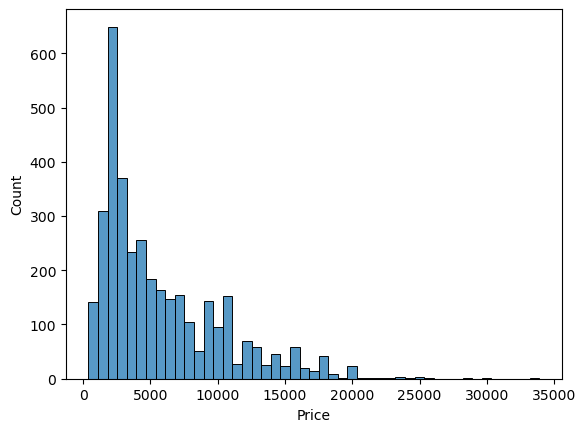

In [633]:
sns.histplot(car_df_clean['Price'])

<Axes: ylabel='Price'>

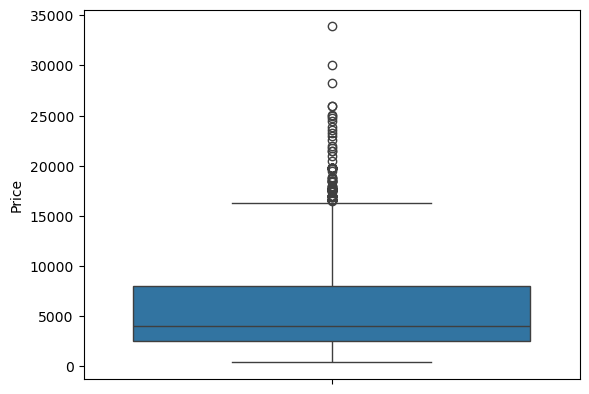

In [634]:
sns.boxplot(car_df_clean['Price'])

<Axes: xlabel='None', ylabel='Price'>

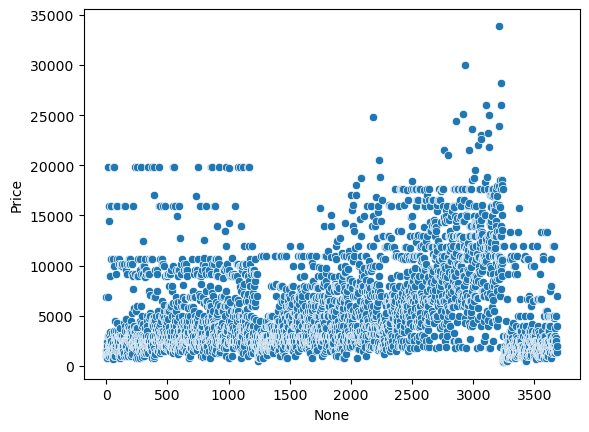

In [635]:
sns.scatterplot(x=car_df_clean.index, y=car_df_clean['Price'])

In [636]:
car_df_clean[car_df_clean['Price'] > 30000]

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,brand,country
3212,MERCEDES-BENZ GLE CLASS,33900,92000,2019,Diesel,SUV,2.0,Automatic,5.0,5.0,6.0,mercedes-benz,Germany


찾아보니 2019년식 메르세데스 벤츠 가격 65,807~76,100유로...  
33,900유로면 정상적인 데이터인듯 보임...(제거 안함)  
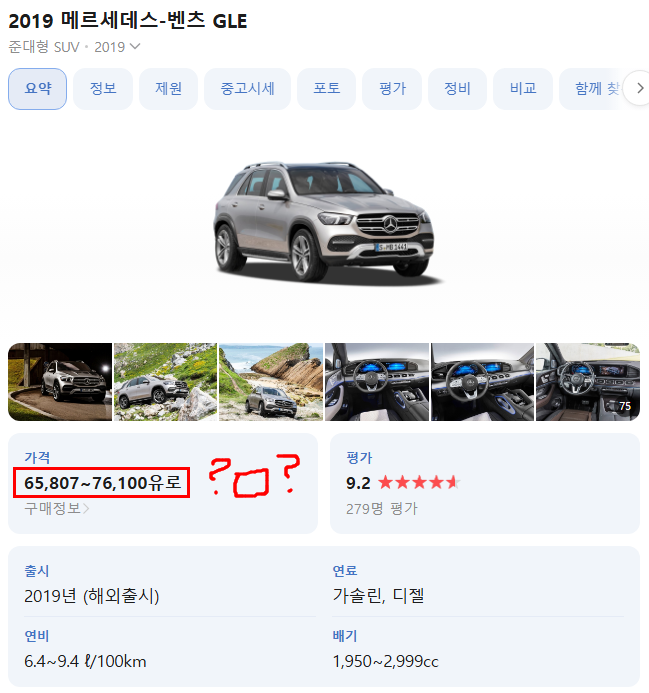


In [637]:
car_df_clean['Mileage(miles)'].sort_values()

3219          1
3100          1
2013          6
3102        222
2760       1048
         ...   
1685     274100
1933     274100
1946     274100
2048     274100
1037    1110100
Name: Mileage(miles), Length: 3593, dtype: int64

In [638]:
car_df_clean[car_df_clean['Mileage(miles)'] > 300000]

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,brand,country
1037,VOLKSWAGEN BEETLE,2495,1110100,2003,Petrol,Hatchback,2.0,Automatic,3.0,4.0,4.0,volkswagen,Germany


<Axes: ylabel='Mileage(miles)'>

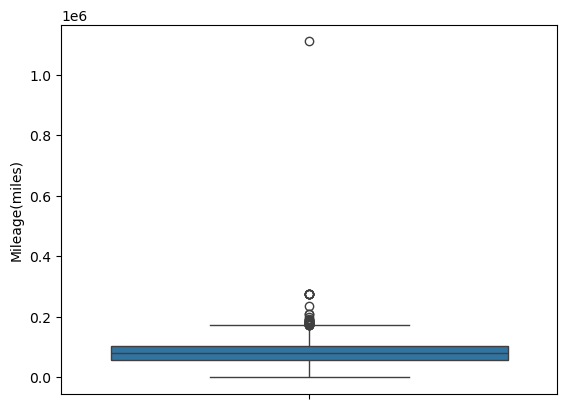

In [639]:
sns.boxplot(car_df_clean['Mileage(miles)'])

<Axes: xlabel='None', ylabel='Mileage(miles)'>

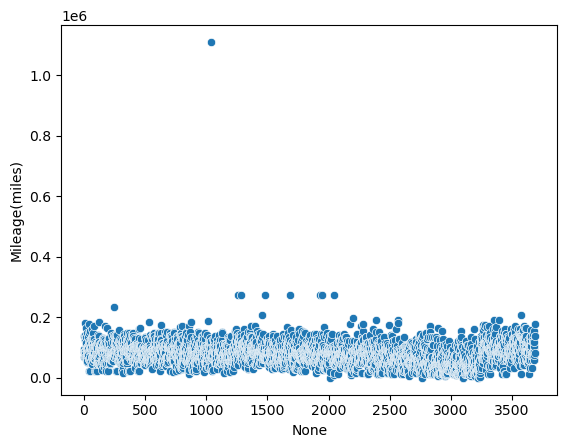

In [640]:
sns.scatterplot(x=car_df_clean.index, y=car_df_clean['Mileage(miles)'])

연 평균 주행거리(영국): 약 10,000 ~ 12,000 miles  
20년이면 240,000 miles  
택시·상용차 같은 극단적인 경우도  
→ 300,000 ~ 400,000 miles가 상한선  

1,110,100 miles = 178만 km  
→ 승용차로는 거의 불가능한 수치  

🚨 당장 이상치 처리해!!!

<Axes: ylabel='Mileage(miles)'>

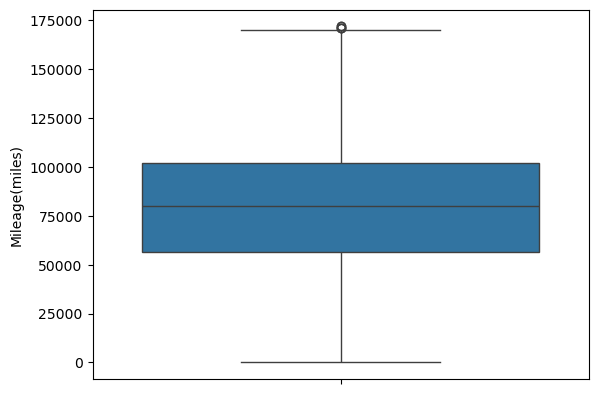

In [641]:
Q1 = car_df_clean['Mileage(miles)'].quantile(0.25)
Q3 = car_df_clean['Mileage(miles)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

car_df_clean = car_df_clean[(car_df_clean['Mileage(miles)'] >= lower) & (car_df_clean['Mileage(miles)'] <= upper)]
sns.boxplot(car_df_clean['Mileage(miles)'])

In [642]:
car_df_clean['Mileage(miles)'].sort_values()

3219         1
3100         1
2013         6
3102       222
2760      1048
         ...  
1365    171000
173     171000
85      171090
3311    172000
1402    172000
Name: Mileage(miles), Length: 3560, dtype: int64

이상치가 너무 이상치...  
👌 IQR 방식으로 제거 완료!

## 5. 상관관계 확인

In [643]:
car_df_clean.head()

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,brand,country
0,SKODA FABIA,6900,70189,2016,Diesel,Hatchback,1.4,Manual,5.0,5.0,6.0,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,Petrol,Hatchback,1.2,Manual,3.0,5.0,4.0,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,Petrol,Hatchback,1.4,Manual,5.0,5.0,5.0,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,Petrol,Hatchback,1.4,Manual,3.0,4.0,4.0,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,Diesel,Hatchback,1.3,Manual,5.0,5.0,5.0,vauxhall,United Kingdom


In [644]:
car_df_clean['Fuel type'].unique()

array(['Diesel', 'Petrol', 'Petrol Plug-in Hybrid', 'Petrol Hybrid',
       'Diesel Hybrid'], dtype=object)

In [645]:
car_df_clean['Body type'].unique()

array(['Hatchback', 'Coupe', 'Saloon', 'Convertible', 'Estate', 'MPV',
       'SUV', 'Pickup', 'Combi Van'], dtype=object)

In [646]:
car_df_clean['Gearbox'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [647]:
car_df_clean["Gearbox"] = car_df_clean["Gearbox"]. replace({"Manual": 0, "Automatic": 1})

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_11648\1700960935.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_df_clean["Gearbox"] = car_df_clean["Gearbox"]. replace({"Manual": 0, "Automatic": 1})


수동 : 0  
자동 : 1  
해당 변수는 수동, 자동밖에 없어서 숫자형으로 변환해줌

In [648]:
car_df_clean.head()

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,brand,country
0,SKODA FABIA,6900,70189,2016,Diesel,Hatchback,1.4,0,5.0,5.0,6.0,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,Petrol,Hatchback,1.2,0,3.0,5.0,4.0,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,Petrol,Hatchback,1.4,0,5.0,5.0,5.0,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,Petrol,Hatchback,1.4,0,3.0,4.0,4.0,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,Diesel,Hatchback,1.3,0,5.0,5.0,5.0,vauxhall,United Kingdom


In [649]:
car_df_clean['brand'].unique()

array(['skoda', 'vauxhall', 'hyundai', 'mini', 'ford', 'peugeot', 'bmw',
       'citroen', 'mercedes-benz', 'mazda', 'saab', 'volkswagen', 'honda',
       'mg', 'toyota', 'volvo', 'seat', 'nissan', 'alfa', 'kia', 'proton',
       'fiat', 'renault', 'audi', 'mitsubishi', 'lexus', 'land',
       'chevrolet', 'suzuki', 'dacia', 'daihatsu', 'jeep', 'jaguar',
       'chrysler', 'rover', 'ds', 'daewoo', 'dodge', 'subaru', 'porsche',
       'infiniti', 'abarth', 'smart', 'maserati', 'ssangyong'],
      dtype=object)

In [650]:
car_df_clean['country'].unique()

array(['Czech Republic', 'United Kingdom', 'South Korea', 'United States',
       'France', 'Germany', 'Japan', 'Sweden', 'Spain', 'Italy',
       'Malaysia', 'Romania'], dtype=object)

In [651]:
corr = car_df_clean.select_dtypes(include="number").corr()
corr

,Price,Mileage(miles),Registration_Year,Engine,Gearbox,Doors,Seats,Emission Class
Price,1.000000,-0.563552,0.785035,-0.016345,0.214089,0.115813,-0.023682,0.702696
Mileage(miles),-0.563552,1.000000,-0.481514,0.344027,0.088805,-0.033687,0.119755,-0.409624
Registration_Year,0.785035,-0.481514,1.000000,-0.289011,-0.083073,0.216834,0.028602,0.918767
Engine,-0.016345,0.344027,-0.289011,1.000000,0.475214,-0.059621,0.073178,-0.254966
Gearbox,0.214089,0.088805,-0.083073,0.475214,1.000000,-0.082067,-0.006486,-0.080807
Doors,0.115813,-0.033687,0.216834,-0.059621,-0.082067,1.000000,0.498304,0.181828
Seats,-0.023682,0.119755,0.028602,0.073178,-0.006486,0.498304,1.000000,0.025426
Emission Class,0.702696,-0.409624,0.918767,-0.254966,-0.080807,0.181828,0.025426,1.000000


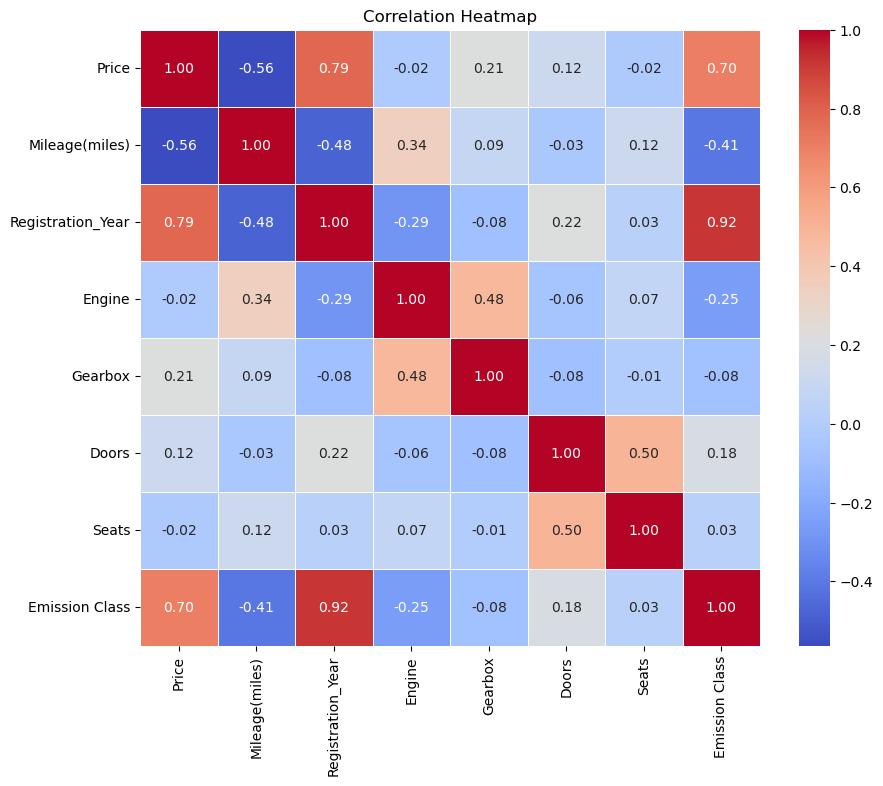

In [652]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [653]:
cluster_df = car_df_clean[["Price", "Mileage(miles)", "Registration_Year",
     "Engine", "Gearbox", "Doors", "Seats", "Emission Class"]]

## 6. Scaler 활용해보기
StandardScaler는 평균 0, 표준편차 1 로 맞춰줌

In [654]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

In [655]:
ss.fit(cluster_df)

,copy,True
,with_mean,True
,with_std,True


In [656]:
cluster_df.columns

Index(['Price', 'Mileage(miles)', 'Registration_Year', 'Engine', 'Gearbox',
       'Doors', 'Seats', 'Emission Class'],
      dtype='object')

In [657]:
ss_df = pd.DataFrame(ss.transform(cluster_df), columns = cluster_df.columns)
ss_df.describe()

,Price,Mileage(miles),Registration_Year,Engine,Gearbox,Doors,Seats,Emission Class
count,3.560000e+03,3.560000e+03,3.560000e+03,3.560000e+03,3.560000e+03,3.560000e+03,3.560000e+03,3.560000e+03
mean,9.580351e-17,-3.193450e-17,1.793122e-14,5.349030e-16,-3.592632e-17,3.432959e-16,7.554506e-16,4.790176e-17
std,1.000140e+00,1.000140e+00,1.000140e+00,1.000140e+00,1.000140e+00,1.000140e+00,1.000140e+00,1.000140e+00
min,-1.200183e+00,-2.385638e+00,-4.011820e+00,-1.653768e+00,-5.078883e-01,-2.350701e+00,-5.040090e+00,-4.363600e+00
25%,-7.367324e-01,-7.053486e-01,-8.432821e-01,-8.240581e-01,-5.078883e-01,-1.336707e+00,1.778396e-01,-1.026215e+00
50%,-4.037055e-01,-3.292479e-03,1.661406e-03,5.651816e-03,-5.078883e-01,6.912821e-01,1.778396e-01,8.624704e-02
75%,5.070992e-01,6.518606e-01,8.466049e-01,4.205068e-01,-5.078883e-01,6.912821e-01,1.778396e-01,1.198709e+00
max,6.211479e+00,2.736439e+00,2.325256e+00,9.754744e+00,1.968937e+00,6.912821e-01,3.656459e+00,1.198709e+00


## 7. 기존 데이터의 정보 70% 이상을 가지는 수준에서 최소한의 주성분 추출 (PCA)

In [658]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(ss_df)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [659]:
pca = PCA(3)

In [660]:
pd.DataFrame(pca.fit_transform(ss_df), columns=['PC1','PC2','PC3'])

,PC1,PC2,PC3
0,1.517768,-0.128987,0.704675
1,-1.505634,-1.406574,-0.033404
2,-1.018358,-0.258260,1.296273
3,-1.391501,-1.708243,-1.186067
4,-0.137754,-0.611263,1.127455
...,...,...,...
3555,-1.442460,-0.235196,1.041162
3556,-1.491720,-0.429821,0.948172
3557,-0.478810,0.428279,0.011041
3558,-0.913295,0.373564,0.240685


In [661]:
(pca.explained_variance_ratio_).sum()

np.float64(0.7690198510860182)

일단 3차원으로 축소시키면 70% 이상 설명할 수 있음

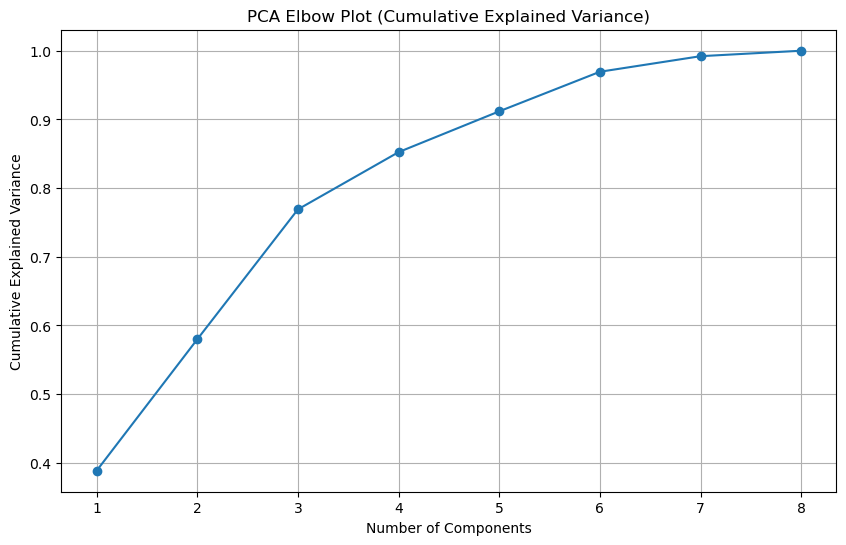

In [662]:
pca = PCA()
pca.fit(ss_df)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Elbow Plot (Cumulative Explained Variance)")
plt.grid(True)
plt.show()

In [677]:
pca = PCA(n_components=3, random_state=42)
pca_data = pca.fit_transform(ss_df)

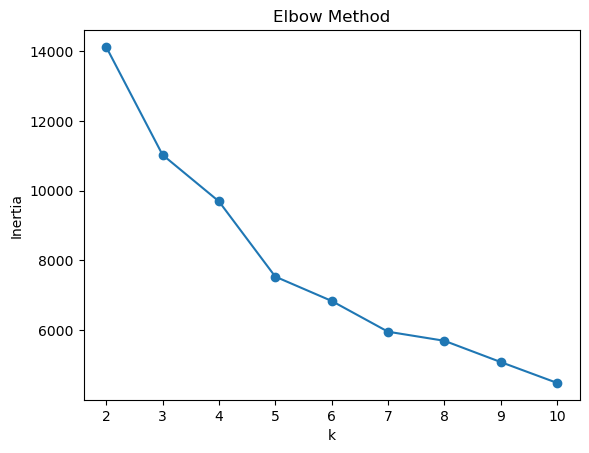

In [678]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(pca_data)
    inertia.append(km.inertia_)

plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [689]:
from sklearn.metrics import silhouette_score

kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = kmeans4.fit_predict(pca_data)

sil4 = silhouette_score(pca_data, labels4)
print("Silhouette(k=4):", sil4)

Silhouette(k=4): 0.3458736686070991


In [690]:
car_df_clean["cluster"] = labels4

car_df_clean["cluster"].value_counts()

cluster
2    1223
3    1058
0     789
1     490
Name: count, dtype: int64

In [693]:
ks = range(2, 11)
scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_data)
    scores.append(silhouette_score(pca_data, labels))

scores

[0.354664583494257,
 0.3621685557792738,
 0.3458736686070991,
 0.35623869332211566,
 0.31660028745922525,
 0.33210767090075977,
 0.34664143365065414,
 0.3507860045600034,
 0.36429721405073767]

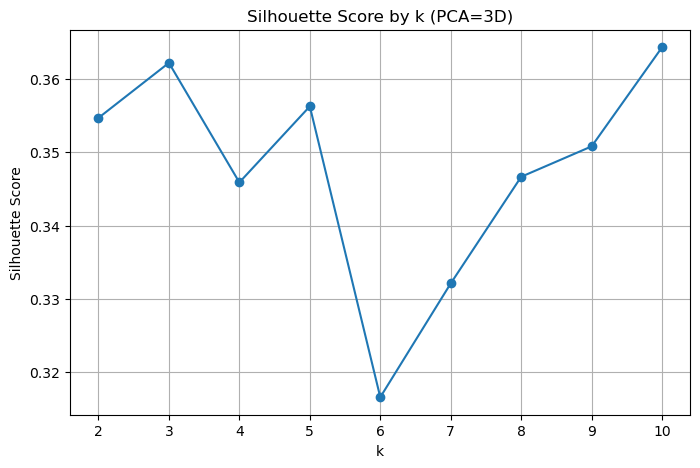

In [692]:
plt.figure(figsize=(8,5))
plt.plot(list(ks), scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k (PCA=3D)")
plt.grid(True)
plt.show()

k=3 이 k=4 보다 실루엣 점수가 높게 나옴  
두가지를 비교해보자!

In [694]:
# k=3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
car_df_clean["cluster_3"] = kmeans3.fit_predict(pca_data)

profile_3 = car_df_clean.groupby("cluster_3")[cluster_df.columns].mean()

# k=4
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
car_df_clean["cluster_4"] = kmeans4.fit_predict(pca_data)

profile_4 = car_df_clean.groupby("cluster_4")[cluster_df.columns].mean()

In [695]:
profile_3

,Price,Mileage(miles),Registration_Year,Engine,Gearbox,Doors,Seats,Emission Class
cluster_3,,,,,,,,
0,3069.112234,91418.846809,2009.718085,1.516330,0.005851,4.192021,4.897872,4.494681
1,10832.069930,52683.297203,2017.296329,1.434441,0.174825,4.604895,4.884615,5.905594
2,4802.516791,98985.958955,2008.647388,2.228731,0.968284,4.149254,4.925373,4.324627


In [696]:
profile_4

,Price,Mileage(miles),Registration_Year,Engine,Gearbox,Doors,Seats,Emission Class
cluster_4,,,,,,,,
0,3277.020279,81862.474018,2009.673004,1.375539,0.034221,3.012674,4.475285,4.506971
1,4871.748980,101007.714286,2008.716327,2.276939,0.977551,4.183673,4.936735,4.340816
2,3237.387572,95585.971382,2010.027800,1.610303,0.022895,4.905151,5.136549,4.552739
3,11156.821361,51236.940454,2017.509452,1.432798,0.185255,4.675803,4.918715,5.929112


In [697]:
print(car_df_clean["cluster_3"].value_counts())
print(car_df_clean["cluster_4"].value_counts())

cluster_3
0    1880
1    1144
2     536
Name: count, dtype: int64
cluster_4
2    1223
3    1058
0     789
1     490
Name: count, dtype: int64


In [698]:
pca_2d = PCA(n_components=2, random_state=42)
pca_2d_data = pca_2d.fit_transform(ss_df)

viz_df = pd.DataFrame(
    pca_2d_data,
    columns=["PC1", "PC2"],
    index=car_df_clean.index
)

viz_df["cluster_3"] = car_df_clean["cluster_3"]
viz_df["cluster_4"] = car_df_clean["cluster_4"]

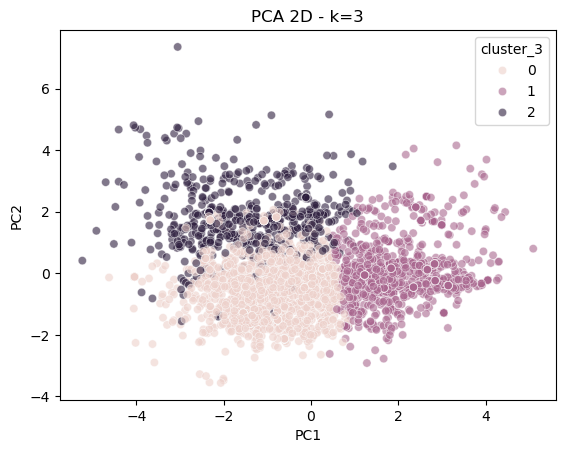

In [699]:
sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="cluster_3", alpha=0.6)
plt.title("PCA 2D - k=3")
plt.show()

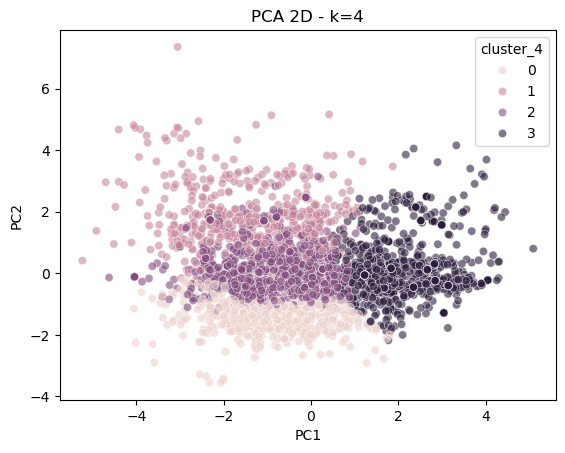

In [700]:
sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="cluster_4", alpha=0.6)
plt.title("PCA 2D - k=4")
plt.show()

## 🔑 중고차 시장 군집 분석 (k = 4) 
군집 개수는 엘보우 메서드 활용하였을 때 4개로 결정하였는데, 실루엣 스코어를 봤을 때는 3개가 가장 높은 점수가 나와서...
어떻게 나누는게 더 좋은 판단일지 고민하였지만 군집의 개수들과 2D 그래프를 봤을 때, 3개로 나눴을 때보다 4개로 나눴을 때 좀 더 군집 간 분리도 충분히 유지되면서도 중고차 시장의 특성을 보다 세분화하여 해석 할 수 있는 구조라고 생각해서 4개로 결정하게 되었습니다.

In [701]:
cluster_profile = car_df_clean.groupby("cluster")[["Price", "Mileage(miles)", "Registration_Year", "Engine", "Gearbox", "Doors", "Seats", "Emission Class"]].mean()

cluster_profile

,Price,Mileage(miles),Registration_Year,Engine,Gearbox,Doors,Seats,Emission Class
cluster,,,,,,,,
0,3277.020279,81862.474018,2009.673004,1.375539,0.034221,3.012674,4.475285,4.506971
1,4871.748980,101007.714286,2008.716327,2.276939,0.977551,4.183673,4.936735,4.340816
2,3237.387572,95585.971382,2010.027800,1.610303,0.022895,4.905151,5.136549,4.552739
3,11156.821361,51236.940454,2017.509452,1.432798,0.185255,4.675803,4.918715,5.929112


- Cluster 0 : “소형/구형/저문(3도어) 차량군”  
문 개수가 평균 2.8이라는 건 3도어 차량이 많음 -> 해치백/소형차 가능성이 커서 작고 단순한 구형 경차/소형차 그룹

- Cluster 1 : “고배기량/자동 중심의 장거리 운행 차량군”  
연식 오래됨 + 주행거리 많음인데 엔진 크고 자동이 많다 -> 구형이지만 엔진 스펙은 좋은 차량 그룹

- Cluster 2 : “일반 대중형 패밀리카(표준형)”  
5도어 + 5인승이 많고 엔진도 무난 -> 전형적인 대중형 해치백/세단, 패밀리카 차량 그룹

- Cluster 3 : “최신형 프리미엄/준프리미엄 차량군”  
최신 연식 + 저주행 + 높은 배출등급(환경규제 대응) -> 고가 차량군으로 시장에서 '상태 좋은 최근 차량' 그룹

|Cluster |	특징 요약	| 이름 붙이면|
|----|----|----|
|0|	3도어 비중 높고 소형, 수동, 중저가	| 경차/소형차 그룹|
|1|	엔진 크고 자동 많고 주행거리 높음	|고배기량 자동 중대형 구형차 그룹|
|2|	5도어 5인승 표준형	|대중형 패밀리카 그룹|
|3|	최신, 저주행, 고가, Euro6	|최신 프리미엄 차량 그룹|

## ✨ 최종 결론
종합적으로 보면 중고차 시장이 가격이나 연식 중심만을 가지고 분류된다기 보다는 차량 용도, 등급, 기술 등에 따라 여러가지 복합적인 구조를 가지고 있으며,   
현재 중고차 시장은 **경차 및 소형차 그룹, 구형 고배기량 차량, 대중형 패밀리카, 최신 프리미엄 차량**  
이렇게 네 가지 주요 군집 결과를 토대로 **중고차 가격 전략 수집, 타켓 마케팅, 차량 추천 시스템** 등 다양한 실무적 활용 가능성이 있다고 판단됩니다.

## Step 2. 이런것도 해볼 수 있어요!

### 국가별 총 브랜드 개수는?

In [702]:
country_brand_count = car_df_clean.groupby("country")["brand"].nunique().sort_values(ascending=False)
country_brand_count

country
Japan             10
Germany            6
United Kingdom     6
United States      5
France             4
Italy              4
South Korea        4
Sweden             2
Czech Republic     1
Malaysia           1
Romania            1
Spain              1
Name: brand, dtype: int64

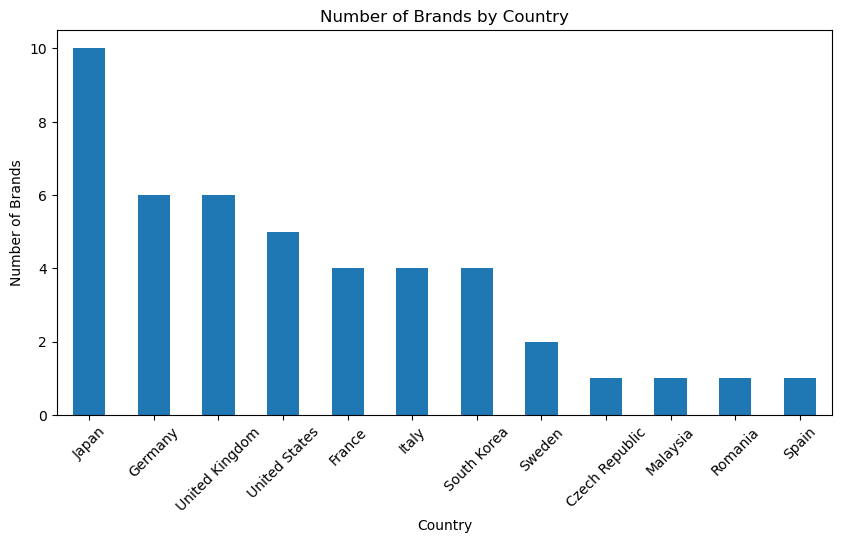

In [703]:
country_brand_count.plot(kind="bar", figsize=(10,5))
plt.title("Number of Brands by Country")
plt.xlabel("Country")
plt.ylabel("Number of Brands")
plt.xticks(rotation=45)
plt.show()